II logistic_regression


Bài toán linear-regression là thuật toán đơn giản và rất hữu dụng trong nhiều trường hợp nhưng  
xét ví dụ bài toán phân loại như sau 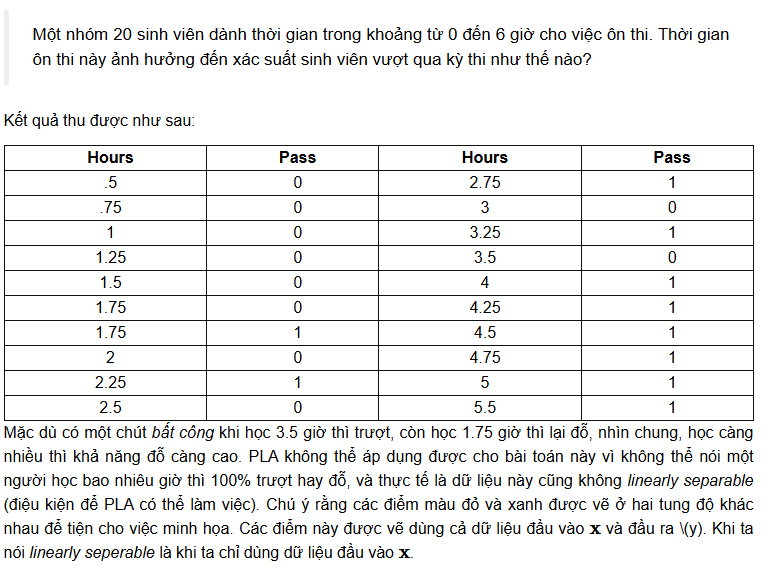  
thì nó lại không phù hợp nữa. Lúc này người ta cần phát triển tìm một thuật toán có khả lăng flexible hơn là logistic-regresion 


### Tại sao mô hình linear_regression lại không phù hợp  

bài toán này thuộc vào loại bài toán phân loại chỉ có 2 lựa chọn pass(1) và không pass(0) vậy nếu mà sử dụng linear_regression thì nó sẽ không thể bị giới hạn trong (0;1) được mặc dù cta có một trick khá hữu ích cho việc này đó là cắt đoạn linear để nó phù hợp nhưng như vậy thì nó rất dễ bị ảnh hưởng khi có thêm 1 giá trị nằm xa khoảng cách trung tâm của linear ví dụ như bài toán trên ta thêm sinh viên học 20 tiếng và đỗ => khi xét trong linear thì giá trị $(y_i -y)^2$ rất dễ bị lệnh nó làm ảnh hưởng đến các giá trị khác rất nhiều.Lúc này đường thẳng linears sẽ được kéo dài ra để đáp ứng bới sinh viên học 20 tiếng điều đó dẫn tới các phán đoán sai về các sinh viên khác  
Vậy giải pháp ở đây : coi bài toán trở thành dạng xác suất chúng ta sử dụng một mô hình flex hơn là logistic-regresion

### Sự khác biệt giữa 2 mô hình linear_regression với logistic_regression là về hàm mục tiêu  

##### linear_regression  
$f(x) = w^Tx$  
##### logistic_regression 
$f(x) = \beta(w^Tx)$  

với giá trị $\beta$ là logistic function ở đây $\beta = \frac{1}{1 + e^{-s}}$  
tại sao lại sử dụng hàm này vì nó giúp mô hình chặn trong khoảng giá trị (0,1) và nó cũng giúp đạo hàm của hàm mục tiêu trở nên đơn giản hơn  

Từ dữ kiện training của mô hình trên ta xây dựng được hai hàm xác suất có điều kiện của  mục tiêu như sau  
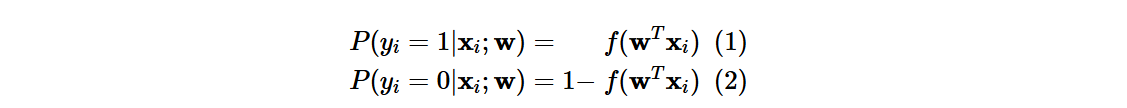  

trong đó    $P(y_i = 1 \mid x_i; w)$ được hiểu là xác suất xảy ra của sự kiện $y_i = 1$  khi biết tham số mô hình w và dữ liệu đầu vào $x_i$ => mục đích của chúng ta là tìm các hệ số w sao cho $f(w^Tx_i) càng gần  với 1 càng tốt với các điểm dữ liệu thuộc class 1 và càng gần 0 càng tốt 

đặt $z_i = f(w^Tx_i)$ và gộp 2 biểu thức trên ta được  
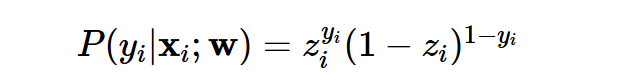  


Vậy mục tiêu của chúng ta ở đây là cần tìm w để  
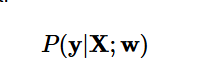 giá trị này đạt lớn nhất 
hay $- P(y \mid X; w)$ đạt giá trị min ( chính là hàm mất mát)

Bài toán tìm tham số này có tên gọi chung là maximum likelihood estimation ( tối ưu hóa ước lượng likelihood) hay nói cách khác chúng ta cần tim w sao cho  
$ w = \arg\max_{w} P(y \mid X; w)$  

giả sử các điểm dữ liệu được sinh ra một cách độc lập ta khai triển likelihood function trở thành  
$
P(\mathbf{y} \mid \mathbf{X}; w)
= \prod_{i=1}^{N} P(y_i \mid x_i; w)
= \prod_{i=1}^{N} z_i^{y_i} (1 - z_i)^{1 - y_i}
$  

Để giải đạo hàm hàm số này sẽ rất phức tạp nên ta sẽ đưa logarit tự nhiên (cơ số e) vào để biến nó trở nên đơn giản hơn  
$J(w) = -\log P(y \mid X; w)
     = - \sum_{i=1}^{N} \left( y_i \log z_i + (1 - y_i)\log(1 - z_i) \right)$  

sau khi đạo hàm ta được  
$\frac{\partial J(w; x_i, y_i)}{\partial w} = (z_i - y_i)x_i$  

và công thức cập nhật trọng số:  
$w = w + \eta (y_i - z_i)x_i$

## Ví dụ 
giải quyết bài toán được nêu ở trên 

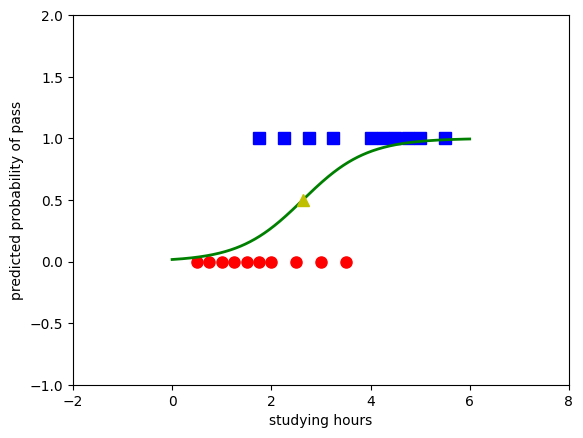

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
np.random.seed(2)

X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# extended data 
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]    
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data 
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # stopping criteria
            if count%check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w
eta = .05 
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)


X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()

## 4 một vài tính chất của logistic regression  
Logistic regression thực chất được sử dụng nhiều trong các loại bài classification ( các dạng bài phân loại thuộc nhóm loại)  
Boundary(miền bao hay là miền phân loại giữa các classification) tạo bởi linear_regression là tuyến tính  

Chứng minh  
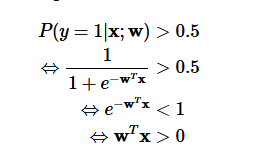

#### hạn chế :  
một kiểu dữ liệu mà logistic Regression không làm việc được với các dữ liệu không gần như linearly separable  
2 là nó yêu cầu các điểm dữ liệu được tạo ra một cách độc lập với nhau. Trên thực tế là vẫn sẽ có thể bị ảnh hưởng bởi nhau. nhưng người ta thường giả sử các điểm là độc lập khi xây dựng mô hình để hàm likelihood trở nên đơn giản dễ tính toán hơn 